Dispositivo computacional configurado: cpu
Using Colab cache for faster access to the 'obesity-levels' dataset.
Dataset de Obesidade carregado. Dimensao original: (2111, 17)
Duplicatas removidas: 24. Nova dimensao: (2087, 17)


/tmp/ipykernel_5084/1893688562.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_obesity, y='NObeyesdad', order=class_order, palette='Blues_r', ax=axes[0, 0])
/tmp/ipykernel_5084/1893688562.py:88: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_temp, x='BMI', y='NObeyesdad', order=class_order, palette='Set2', ax=axes[1, 0])
/tmp/ipykernel_5084/1893688562.py:94: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_temp, x='FAF', y='NObeyesdad', order=class_order, palette='crest', ax=axes[1, 1])


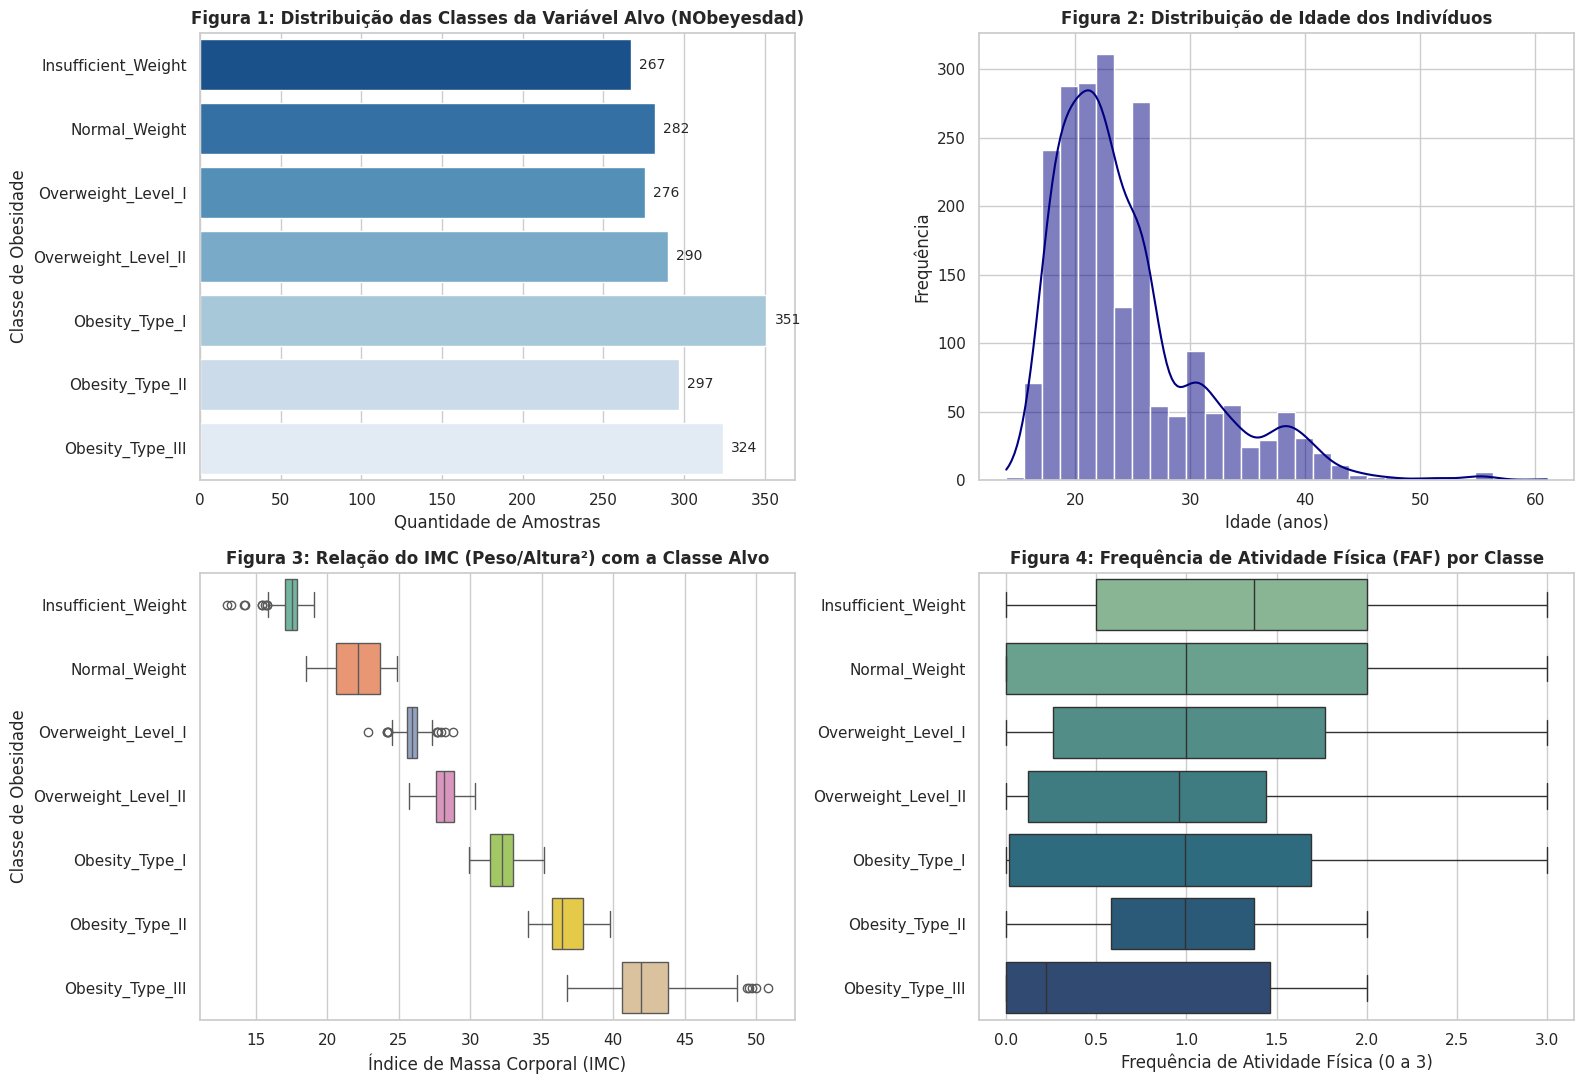

Formatos das matrizes - Treino: (1460, 23) | Validação: (313, 23) | Teste: (314, 23)
ObesityMLP(
  (network): Sequential(
    (0): Linear(in_features=23, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.2, inplace=False)
    (12): Linear(in_features=32, out_features=7, bias=True)
  )
)
Iniciando treinamento da rede neural de classificação...
Epoca [01/40] | Train Loss: 1.9762 (Acc: 27.9%) | Val Loss: 1.4135 (Acc: 43.8%) | Grad Norm: 2.4083
Epoca [10/40] | Train Loss: 0.7737 (Ac

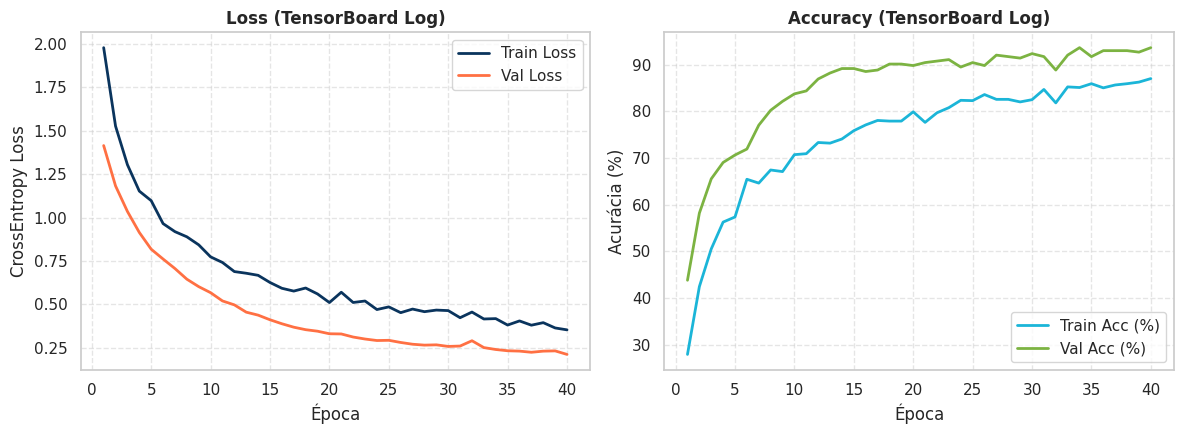

Acuracia do Baseline (Arvore de Decisao - Max Depth 4): 76.75%
Acuracia da MLP PyTorch no Conjunto de Teste:        94.90%

Relatorio de Classificacao Detalhado (MLP):
                     precision    recall  f1-score   support

Insufficient_Weight       0.95      1.00      0.98        40
      Normal_Weight       0.92      0.86      0.89        42
     Obesity_Type_I       0.98      0.96      0.97        53
    Obesity_Type_II       1.00      0.98      0.99        45
   Obesity_Type_III       1.00      1.00      1.00        49
 Overweight_Level_I       0.86      0.88      0.87        41
Overweight_Level_II       0.91      0.95      0.93        44

           accuracy                           0.95       314
          macro avg       0.95      0.95      0.95       314
       weighted avg       0.95      0.95      0.95       314



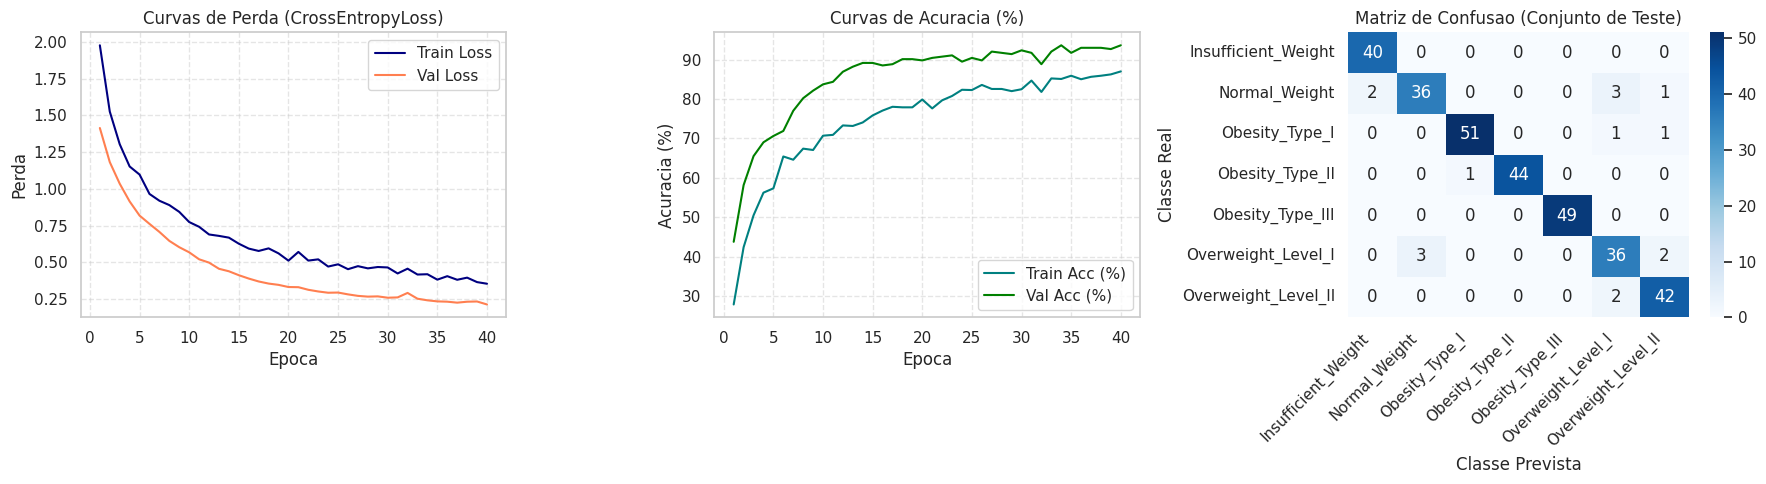

Treinando configuracao: Config_A_ReLU_He_BatchNorm...
Treinando configuracao: Config_B_LeakyReLU_Xavier_LayerNorm...
Treinando configuracao: Config_C_ReLU_Default_NoNorm...


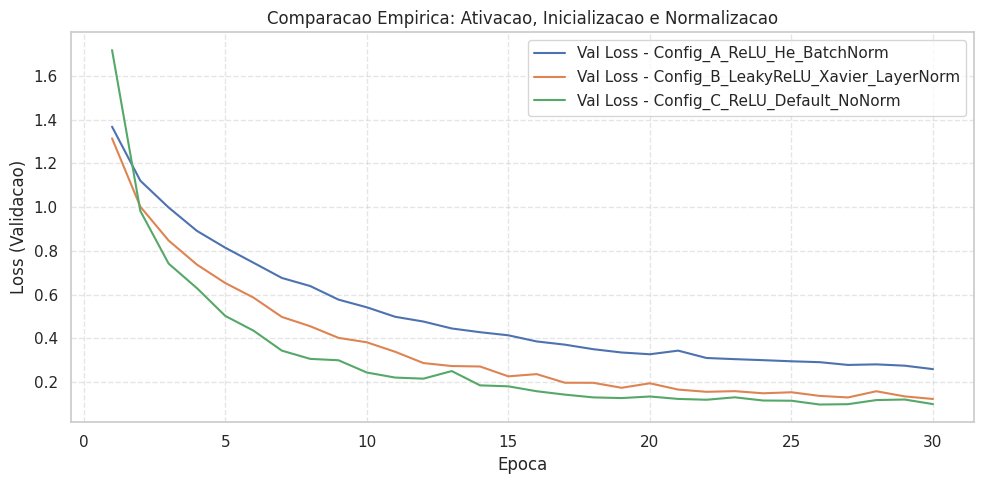

Using Colab cache for faster access to the 'flight-price-prediction' dataset.
✅ Dataset de Regressão selecionado: Data_Train.csv
📊 Dimensão original: (10683, 11)


/tmp/ipykernel_5084/1893688562.py:546: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_flight, x=cat_col_plot, y=price_col, palette='Set2', ax=axes[1])


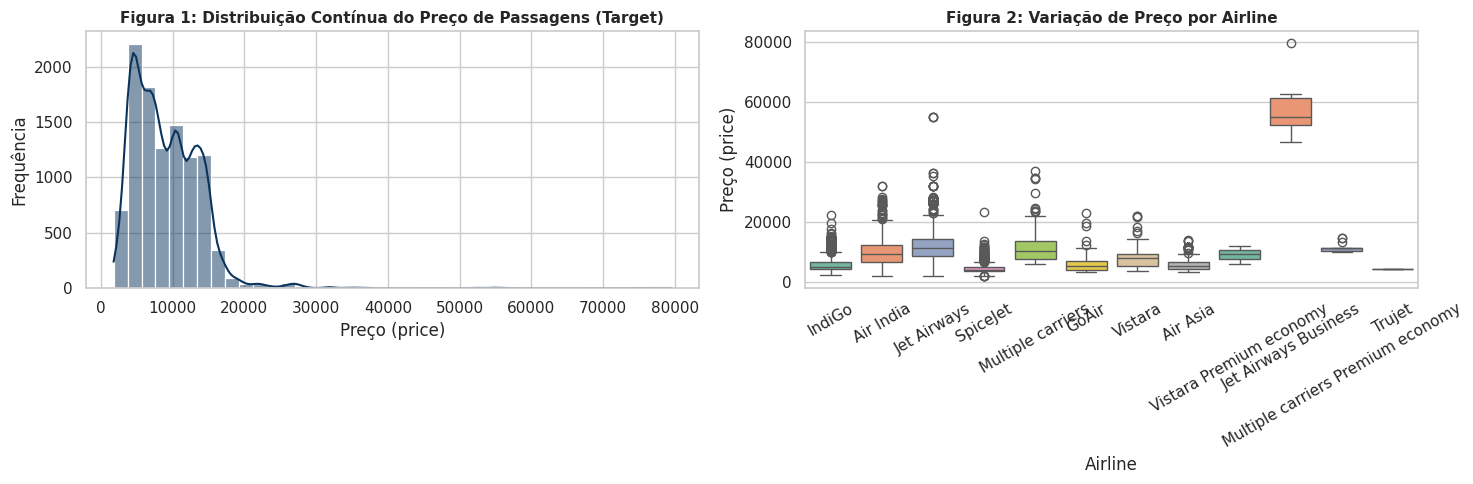

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


Formatos das matrizes - Treino: (7323, 32) | Validação: (1569, 32) | Teste: (1570, 32)
Iniciando treinamento da MLP de Regressao...
Epoca [01/50] | Train MSE: 0.5308 | Val MSE: 0.2615 | Grad Norm: 1.7256
Epoca [10/50] | Train MSE: 0.2381 | Val MSE: 0.1652 | Grad Norm: 0.8517
Epoca [20/50] | Train MSE: 0.2182 | Val MSE: 0.1820 | Grad Norm: 0.6965
Epoca [30/50] | Train MSE: 0.2004 | Val MSE: 0.1754 | Grad Norm: 0.6500
Epoca [40/50] | Train MSE: 0.1964 | Val MSE: 0.1855 | Grad Norm: 0.6178
Epoca [50/50] | Train MSE: 0.2001 | Val MSE: 0.1855 | Grad Norm: 0.6669
Treinamento de Regressao concluido com sucesso!
METRICAS DE REGRESSAO NO CONJUNTO DE TESTE
Baseline Ridge Regression -> R²: 0.6482 | MAE: 1,791.62
MLP PyTorch (128-64-32)   -> R²: 0.8231 | MAE: 1,154.41
                             RMSE: 1,901.85


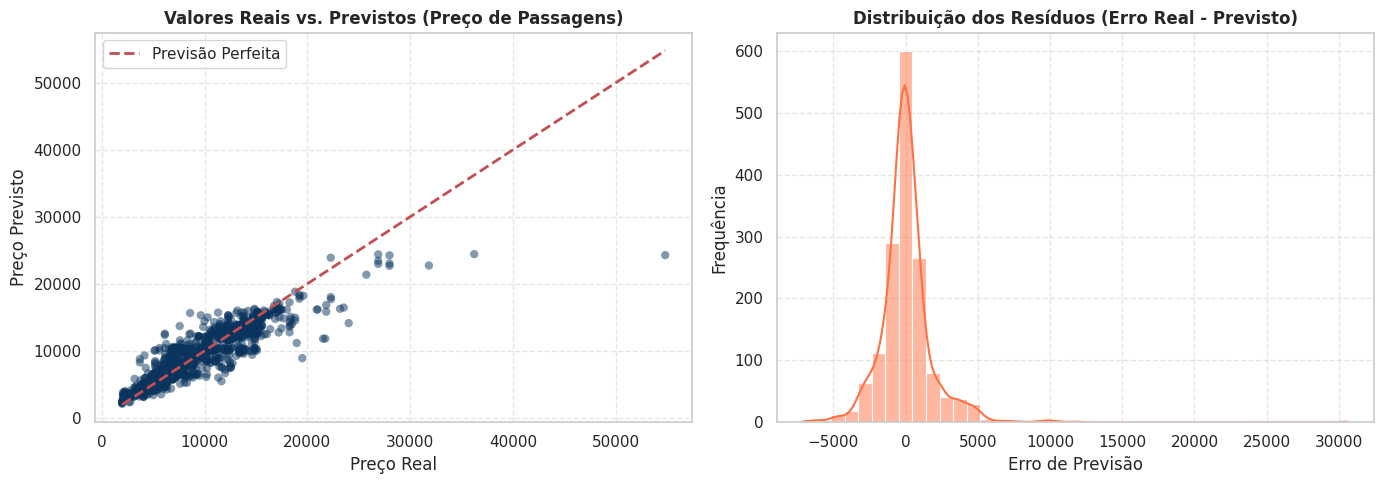

In [2]:
# -*- coding: utf-8 -*-
"""
Projeto 1: Pipeline MLP - Classificação e Regressão
Disciplina: Redes Neurais Profundas
Autor: Vítor Turci dos Santos Nogueira
"""

# ==============================================================================
# PARTE 1: CLASSIFICAÇÃO MULTICLASSE (OBESIDADE)
# ==============================================================================

# 1. Configuração do Ambiente e Importações
!pip install -q kagglehub

import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.utils.tensorboard import SummaryWriter

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.tree import DecisionTreeClassifier
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator
import kagglehub

def set_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Dispositivo computacional configurado:", device)

# 2. Carregamento e Auditoria dos Dados
dataset_dir = kagglehub.dataset_download("ankurbajaj9/obesity-levels")
csv_file = [f for f in os.listdir(dataset_dir) if f.endswith('.csv')][0]
csv_path = os.path.join(dataset_dir, csv_file)

df_obesity = pd.read_csv(csv_path)

print(f"Dataset de Obesidade carregado. Dimensao original: {df_obesity.shape}")

# Verificacao e remocao de duplicatas
duplicates = df_obesity.duplicated().sum()
if duplicates > 0:
    df_obesity = df_obesity.drop_duplicates().reset_index(drop=True)
    print(f"Duplicatas removidas: {duplicates}. Nova dimensao: {df_obesity.shape}")

# 3. Análise Exploratória de Dados (EDA)
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 11), facecolor='white')

class_order = [
    'Insufficient_Weight', 'Normal_Weight', 'Overweight_Level_I',
    'Overweight_Level_II', 'Obesity_Type_I', 'Obesity_Type_II', 'Obesity_Type_III'
]

# Figura 1: Distribuição das Classes Alvo
sns.countplot(data=df_obesity, y='NObeyesdad', order=class_order, palette='Blues_r', ax=axes[0, 0])
axes[0, 0].set_title('Figura 1: Distribuição das Classes da Variável Alvo (NObeyesdad)', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Quantidade de Amostras')
axes[0, 0].set_ylabel('Classe de Obesidade')
for p in axes[0, 0].patches:
    width = p.get_width()
    axes[0, 0].annotate(f'{int(width)}', (width + 5, p.get_y() + p.get_height() / 2.), ha='left', va='center', fontsize=10)

# Figura 2: Distribuição de Idade
sns.histplot(df_obesity['Age'], kde=True, color='navy', bins=30, ax=axes[0, 1])
axes[0, 1].set_title('Figura 2: Distribuição de Idade dos Indivíduos', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Idade (anos)')
axes[0, 1].set_ylabel('Frequência')

# Figura 3: Relação do IMC por Classe
df_temp = df_obesity.copy()
df_temp['BMI'] = df_temp['Weight'] / (df_temp['Height'] ** 2)
sns.boxplot(data=df_temp, x='BMI', y='NObeyesdad', order=class_order, palette='Set2', ax=axes[1, 0])
axes[1, 0].set_title('Figura 3: Relação do IMC (Peso/Altura²) com a Classe Alvo', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Índice de Massa Corporal (IMC)')
axes[1, 0].set_ylabel('Classe de Obesidade')

# Figura 4: Frequência de Atividade Física (FAF)
sns.boxplot(data=df_temp, x='FAF', y='NObeyesdad', order=class_order, palette='crest', ax=axes[1, 1])
axes[1, 1].set_title('Figura 4: Frequência de Atividade Física (FAF) por Classe', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Frequência de Atividade Física (0 a 3)')
axes[1, 1].set_ylabel('')

plt.tight_layout()
plt.savefig('analise_exploratoria_obesidade.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

# 4. Divisão e Pré-processamento
X_raw = df_obesity.drop(columns=['NObeyesdad'])
y_raw = df_obesity['NObeyesdad'].values

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_raw)
class_names = list(label_encoder.classes_)

X_train_df, X_temp_df, y_train, y_temp = train_test_split(
    X_raw, y_encoded, test_size=0.30, random_state=42, stratify=y_encoded
)
X_val_df, X_test_df, y_val, y_test = train_test_split(
    X_temp_df, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

num_cols = ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']
cat_cols = ['Gender', 'family_history_with_overweight', 'FAVC', 'CAEC', 'SMOKE', 'SCC', 'CALC', 'MTRANS']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), cat_cols)
    ]
)

X_train = preprocessor.fit_transform(X_train_df)
X_val = preprocessor.transform(X_val_df)
X_test = preprocessor.transform(X_test_df)

print(f"Formatos das matrizes - Treino: {X_train.shape} | Validação: {X_val.shape} | Teste: {X_test.shape}")

# 5. Dataset e DataLoaders PyTorch
class ObesityDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

batch_size = 32
train_loader = DataLoader(ObesityDataset(X_train, y_train), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(ObesityDataset(X_val, y_val), batch_size=batch_size, shuffle=False)
test_loader = DataLoader(ObesityDataset(X_test, y_test), batch_size=batch_size, shuffle=False)

# 6. Arquitetura da Rede Neural (ObesityMLP)
class ObesityMLP(nn.Module):
    def __init__(self, input_dim, hidden_dims, num_classes,
                 activation='relu', norm_type='batchnorm', dropout_rate=0.2, init_type='he'):
        super(ObesityMLP, self).__init__()

        layers = []
        in_dim = input_dim

        if activation == 'relu':
            act_cls = nn.ReLU
        elif activation == 'leaky_relu':
            act_cls = lambda: nn.LeakyReLU(0.1)
        else:
            act_cls = nn.ReLU

        for h_dim in hidden_dims:
            layers.append(nn.Linear(in_dim, h_dim))
            if norm_type == 'batchnorm':
                layers.append(nn.BatchNorm1d(h_dim))
            elif norm_type == 'layernorm':
                layers.append(nn.LayerNorm(h_dim))
            layers.append(act_cls())
            if dropout_rate > 0.0:
                layers.append(nn.Dropout(dropout_rate))
            in_dim = h_dim

        layers.append(nn.Linear(in_dim, num_classes))
        self.network = nn.Sequential(*layers)
        self._init_weights(init_type)

    def _init_weights(self, init_type):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                if init_type == 'he':
                    nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                elif init_type == 'xavier':
                    nn.init.xavier_normal_(m.weight)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0.0)

    def forward(self, x):
        return self.network(x)

model = ObesityMLP(
    input_dim=X_train.shape[1],
    hidden_dims=[128, 64, 32],
    num_classes=7,
    activation='relu',
    norm_type='batchnorm',
    dropout_rate=0.2,
    init_type='he'
).to(device)

print(model)

# 7. Treinamento da Rede Neural e Registro no TensorBoard
writer = SummaryWriter(log_dir='runs/obesity_classification_experiment')

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

epochs = 40
best_val_loss = float('inf')
checkpoint_path = 'best_obesity_mlp.pt'

train_losses, val_losses = [], []
train_accs, val_accs = [], []
grad_norms = []

print("Iniciando treinamento da rede neural de classificação...")

for epoch in range(1, epochs + 1):
    model.train()
    t_loss, t_corr, t_total = 0.0, 0, 0
    total_grad_norm = 0.0

    for X_b, y_b in train_loader:
        X_b, y_b = X_b.to(device), y_b.to(device)
        optimizer.zero_grad()
        outputs = model(X_b)
        loss = criterion(outputs, y_b)
        loss.backward()

        gnorm = 0.0
        for p in model.parameters():
            if p.grad is not None:
                gnorm += p.grad.data.norm(2).item() ** 2
        gnorm = math.sqrt(gnorm)
        total_grad_norm += gnorm

        optimizer.step()

        t_loss += loss.item() * X_b.size(0)
        _, preds = torch.max(outputs, 1)
        t_corr += (preds == y_b).sum().item()
        t_total += y_b.size(0)

    ep_t_loss = t_loss / t_total
    ep_t_acc = t_corr / t_total
    ep_g_norm = total_grad_norm / len(train_loader)

    model.eval()
    v_loss, v_corr, v_total = 0.0, 0, 0
    with torch.no_grad():
        for X_b, y_b in val_loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            outputs = model(X_b)
            loss = criterion(outputs, y_b)

            v_loss += loss.item() * X_b.size(0)
            _, preds = torch.max(outputs, 1)
            v_corr += (preds == y_b).sum().item()
            v_total += y_b.size(0)

    ep_v_loss = v_loss / v_total
    ep_v_acc = v_corr / v_total

    scheduler.step(ep_v_loss)

    train_losses.append(ep_t_loss)
    val_losses.append(ep_v_loss)
    train_accs.append(ep_t_acc)
    val_accs.append(ep_v_acc)
    grad_norms.append(ep_g_norm)

    writer.add_scalar('Loss/Train', ep_t_loss, epoch)
    writer.add_scalar('Loss/Val', ep_v_loss, epoch)
    writer.add_scalar('Accuracy/Train', ep_t_acc, epoch)
    writer.add_scalar('Accuracy/Val', ep_v_acc, epoch)
    writer.add_scalar('Diagnostics/Grad_Norm', ep_g_norm, epoch)
    writer.add_scalar('Diagnostics/Learning_Rate', optimizer.param_groups[0]['lr'], epoch)

    if ep_v_loss < best_val_loss:
        best_val_loss = ep_v_loss
        torch.save(model.state_dict(), checkpoint_path)

    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoca [{epoch:02d}/{epochs}] | Train Loss: {ep_t_loss:.4f} (Acc: {ep_t_acc*100:.1f}%) | "
              f"Val Loss: {ep_v_loss:.4f} (Acc: {ep_v_acc*100:.1f}%) | Grad Norm: {ep_g_norm:.4f}")

writer.close()
print("Treinamento de classificação concluido. Modelo salvo em:", checkpoint_path)

# 8. Extração e Plotagem dos Logs do TensorBoard
log_dir = 'runs/obesity_classification_experiment'
event_file = [os.path.join(log_dir, f) for f in os.listdir(log_dir) if 'events.out' in f][0]

ea = EventAccumulator(event_file)
ea.Reload()

train_loss_tb = [s.value for s in ea.Scalars('Loss/Train')]
val_loss_tb = [s.value for s in ea.Scalars('Loss/Val')]
train_acc_tb = [s.value for s in ea.Scalars('Accuracy/Train')]
val_acc_tb = [s.value for s in ea.Scalars('Accuracy/Val')]
steps_tb = [s.step for s in ea.Scalars('Loss/Train')]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), facecolor='white')

axes[0].set_facecolor('white')
axes[0].plot(steps_tb, train_loss_tb, label='Train Loss', color='#0A345D', linewidth=2)
axes[0].plot(steps_tb, val_loss_tb, label='Val Loss', color='#FF7043', linewidth=2)
axes[0].set_title('Loss (TensorBoard Log)', fontweight='bold')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('CrossEntropy Loss')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)

axes[1].set_facecolor('white')
axes[1].plot(steps_tb, [a * 100 for a in train_acc_tb], label='Train Acc (%)', color='#1BB5D8', linewidth=2)
axes[1].plot(steps_tb, [a * 100 for a in val_acc_tb], label='Val Acc (%)', color='#7CB342', linewidth=2)
axes[1].set_title('Accuracy (TensorBoard Log)', fontweight='bold')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Acurácia (%)')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('tensorboard_fundo_branco.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

# 9. Avaliação no Teste, Baseline e Matriz de Confusão
model.load_state_dict(torch.load(checkpoint_path))
model.eval()

y_test_preds = []
with torch.no_grad():
    for X_b, _ in test_loader:
        X_b = X_b.to(device)
        out = model(X_b)
        _, preds = torch.max(out, 1)
        y_test_preds.extend(preds.cpu().numpy())

mlp_acc = accuracy_score(y_test, y_test_preds)

dt_base = DecisionTreeClassifier(max_depth=4, random_state=42)
dt_base.fit(X_train, y_train)
dt_preds = dt_base.predict(X_test)
dt_acc = accuracy_score(y_test, dt_preds)

print("="*60)
print(f"Acuracia do Baseline (Arvore de Decisao - Max Depth 4): {dt_acc*100:.2f}%")
print(f"Acuracia da MLP PyTorch no Conjunto de Teste:        {mlp_acc*100:.2f}%")
print("="*60)

print("\nRelatorio de Classificacao Detalhado (MLP):")
print(classification_report(y_test, y_test_preds, target_names=class_names))

fig, axes = plt.subplots(1, 3, figsize=(18, 5), facecolor='white')

axes[0].set_facecolor('white')
axes[0].plot(range(1, epochs + 1), train_losses, label='Train Loss', color='navy')
axes[0].plot(range(1, epochs + 1), val_losses, label='Val Loss', color='coral')
axes[0].set_title('Curvas de Perda (CrossEntropyLoss)')
axes[0].set_xlabel('Epoca')
axes[0].set_ylabel('Perda')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)

axes[1].set_facecolor('white')
axes[1].plot(range(1, epochs + 1), [a*100 for a in train_accs], label='Train Acc (%)', color='teal')
axes[1].plot(range(1, epochs + 1), [a*100 for a in val_accs], label='Val Acc (%)', color='green')
axes[1].set_title('Curvas de Acuracia (%)')
axes[1].set_xlabel('Epoca')
axes[1].set_ylabel('Acuracia (%)')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.5)

cm = confusion_matrix(y_test, y_test_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[2],
            xticklabels=class_names, yticklabels=class_names)
axes[2].set_title('Matriz de Confusao (Conjunto de Teste)')
axes[2].set_xlabel('Classe Prevista')
axes[2].set_ylabel('Classe Real')
axes[2].set_xticklabels(class_names, rotation=45, ha='right')

plt.tight_layout()
plt.show()

# 10. Experimento Comparativo (Ativação, Inicialização e Normalização)
configs = [
    {
        'label': 'Config_A_ReLU_He_BatchNorm',
        'activation': 'relu',
        'init_type': 'he',
        'norm_type': 'batchnorm'
    },
    {
        'label': 'Config_B_LeakyReLU_Xavier_LayerNorm',
        'activation': 'leaky_relu',
        'init_type': 'xavier',
        'norm_type': 'layernorm'
    },
    {
        'label': 'Config_C_ReLU_Default_NoNorm',
        'activation': 'relu',
        'init_type': 'default',
        'norm_type': None
    }
]

comparison_results = {}

for cfg in configs:
    print(f"Treinando configuracao: {cfg['label']}...")

    exp_model = ObesityMLP(
        input_dim=X_train.shape[1],
        hidden_dims=[128, 64, 32],
        num_classes=7,
        activation=cfg['activation'],
        norm_type=cfg['norm_type'],
        dropout_rate=0.2,
        init_type=cfg['init_type']
    ).to(device)

    exp_optimizer = optim.AdamW(exp_model.parameters(), lr=0.001, weight_decay=1e-4)
    exp_criterion = nn.CrossEntropyLoss()

    t_losses, v_losses = [], []

    for epoch in range(1, 31):
        exp_model.train()
        t_loss, t_total = 0.0, 0
        for X_b, y_b in train_loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            exp_optimizer.zero_grad()
            out = exp_model(X_b)
            loss = exp_criterion(out, y_b)
            loss.backward()
            exp_optimizer.step()
            t_loss += loss.item() * X_b.size(0)
            t_total += y_b.size(0)

        exp_model.eval()
        v_loss, v_total = 0.0, 0
        with torch.no_grad():
            for X_b, y_b in val_loader:
                X_b, y_b = X_b.to(device), y_b.to(device)
                out = exp_model(X_b)
                loss = exp_criterion(out, y_b)
                v_loss += loss.item() * X_b.size(0)
                v_total += y_b.size(0)

        t_losses.append(t_loss / t_total)
        v_losses.append(v_loss / v_total)

    comparison_results[cfg['label']] = {
        'train_loss': t_losses,
        'val_loss': v_losses
    }

plt.figure(figsize=(10, 5), facecolor='white')
for label, res in comparison_results.items():
    plt.plot(range(1, 31), res['val_loss'], label=f"Val Loss - {label}")

plt.title('Comparacao Empirica: Ativacao, Inicializacao e Normalizacao')
plt.xlabel('Epoca')
plt.ylabel('Loss (Validacao)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# ==============================================================================
# PARTE 2: VARIANTE DE REGRESSÃO (FLIGHT PRICE PREDICTION) - CORRIGIDA
# ==============================================================================

import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.utils.tensorboard import SummaryWriter

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import Ridge
import kagglehub

# 1. Carregamento Inteligente do Arquivo de Treino
path_flight = kagglehub.dataset_download("muhammadbinimran/flight-price-prediction")
csv_files_flight = [f for f in os.listdir(path_flight) if f.endswith('.csv')]

# Garantir a escolha do arquivo que contém a coluna 'price' / 'fare'
target_file_flight = None
for f in csv_files_flight:
    temp_path = os.path.join(path_flight, f)
    temp_df = pd.read_csv(temp_path, nrows=5)
    cols_lower = [c.lower().strip() for c in temp_df.columns]
    if any('price' in c or 'fare' in c for c in cols_lower):
        target_file_flight = f
        break

if target_file_flight is None:
    target_file_flight = csv_files_flight[0]

csv_path_flight = os.path.join(path_flight, target_file_flight)
df_flight = pd.read_csv(csv_path_flight)
df_flight.columns = df_flight.columns.str.lower().str.strip()

print(f"✅ Dataset de Regressão selecionado: {target_file_flight}")
print(f"📊 Dimensão original: {df_flight.shape}")

# 2. Análise Exploratória (EDA)
cols_to_drop_flight = [col for col in ['unnamed: 0', 'index', 'id'] if col in df_flight.columns]
if cols_to_drop_flight:
    df_flight = df_flight.drop(columns=cols_to_drop_flight)

duplicates_flight = df_flight.duplicated().sum()
if duplicates_flight > 0:
    df_flight = df_flight.drop_duplicates().reset_index(drop=True)

price_col = 'price' if 'price' in df_flight.columns else [c for c in df_flight.columns if 'price' in c or 'fare' in c][0]
cat_cols_available = df_flight.select_dtypes(include=['object', 'category']).columns.tolist()
cat_col_plot = next((c for c in ['airline', 'class', 'source', 'destination'] if c in cat_cols_available), cat_cols_available[0])

fig, axes = plt.subplots(1, 2, figsize=(15, 5), facecolor='white')

axes[0].set_facecolor('white')
sns.histplot(df_flight[price_col], kde=True, color='#0A345D', bins=40, ax=axes[0])
axes[0].set_title('Figura 1: Distribuição Contínua do Preço de Passagens (Target)', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Preço (price)')
axes[0].set_ylabel('Frequência')

axes[1].set_facecolor('white')
sns.boxplot(data=df_flight, x=cat_col_plot, y=price_col, palette='Set2', ax=axes[1])
axes[1].set_title(f'Figura 2: Variação de Preço por {cat_col_plot.capitalize()}', fontsize=11, fontweight='bold')
axes[1].set_xlabel(cat_col_plot.capitalize())
axes[1].set_ylabel('Preço (price)')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('eda_passagens_aereas.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

# 3. Limpeza, Feature Engineering e Divisão dos Dados
df_flight = df_flight.dropna().reset_index(drop=True)

stops_map = {'non-stop': 0, '1 stop': 1, '2 stops': 2, '3 stops': 3, '4 stops': 4}
if 'total_stops' in df_flight.columns:
    df_flight['stops_num'] = df_flight['total_stops'].map(stops_map).fillna(0)

def duration_to_mins(dur):
    try:
        parts = str(dur).split()
        mins = 0
        for p in parts:
            if 'h' in p:
                mins += int(p.replace('h', '')) * 60
            elif 'm' in p:
                mins += int(p.replace('m', ''))
        return mins
    except:
        return 0

if 'duration' in df_flight.columns:
    df_flight['duration_min'] = df_flight['duration'].apply(duration_to_mins)

if 'date_of_journey' in df_flight.columns:
    date_dt = pd.to_datetime(df_flight['date_of_journey'], format='%d/%m/%Y', errors='coerce')
    df_flight['journey_day'] = date_dt.dt.day.fillna(1)
    df_flight['journey_month'] = date_dt.dt.month.fillna(1)

cols_to_use_flight = ['airline', 'source', 'destination', 'additional_info',
                      'stops_num', 'duration_min', 'journey_day', 'journey_month', price_col]

df_clean_flight = df_flight[[c for c in cols_to_use_flight if c in df_flight.columns]].copy()

X_raw_reg = df_clean_flight.drop(columns=[price_col])
y_raw_reg = df_clean_flight[price_col].values.reshape(-1, 1)

num_cols_reg = X_raw_reg.select_dtypes(include=['int64', 'float64', 'int32']).columns.tolist()
cat_cols_reg = X_raw_reg.select_dtypes(include=['object', 'category']).columns.tolist()

X_train_df_reg, X_temp_df_reg, y_train_raw_reg, y_temp_raw_reg = train_test_split(
    X_raw_reg, y_raw_reg, test_size=0.30, random_state=42
)
X_val_df_reg, X_test_df_reg, y_val_raw_reg, y_test_raw_reg = train_test_split(
    X_temp_df_reg, y_temp_raw_reg, test_size=0.50, random_state=42
)

preprocessor_reg = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols_reg),
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), cat_cols_reg)
    ]
)

X_train_reg = preprocessor_reg.fit_transform(X_train_df_reg)
X_val_reg = preprocessor_reg.transform(X_val_df_reg)
X_test_reg = preprocessor_reg.transform(X_test_df_reg)

y_scaler_reg = StandardScaler()
y_train_reg = y_scaler_reg.fit_transform(y_train_raw_reg).flatten()
y_val_reg = y_scaler_reg.transform(y_val_raw_reg).flatten()
y_test_reg = y_scaler_reg.transform(y_test_raw_reg).flatten()

print(f"Formatos das matrizes - Treino: {X_train_reg.shape} | Validação: {X_val_reg.shape} | Teste: {X_test_reg.shape}")

# 4. Dataset, DataLoader e Arquitetura MLP de Regressão
class FlightDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

batch_size_reg = 64
train_loader_reg = DataLoader(FlightDataset(X_train_reg, y_train_reg), batch_size=batch_size_reg, shuffle=True)
val_loader_reg = DataLoader(FlightDataset(X_val_reg, y_val_reg), batch_size=batch_size_reg, shuffle=False)
test_loader_reg = DataLoader(FlightDataset(X_test_reg, y_test_reg), batch_size=batch_size_reg, shuffle=False)

class FlightPriceMLP(nn.Module):
    def __init__(self, input_dim, hidden_dims=[128, 64, 32], dropout_rate=0.1):
        super(FlightPriceMLP, self).__init__()
        layers = []
        in_dim = input_dim

        for h_dim in hidden_dims:
            layers.append(nn.Linear(in_dim, h_dim))
            layers.append(nn.BatchNorm1d(h_dim))
            layers.append(nn.ReLU())
            if dropout_rate > 0:
                layers.append(nn.Dropout(dropout_rate))
            in_dim = h_dim

        layers.append(nn.Linear(in_dim, 1))
        self.network = nn.Sequential(*layers)

        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0.0)

    def forward(self, x):
        return self.network(x)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_reg = FlightPriceMLP(input_dim=X_train_reg.shape[1]).to(device)

# 5. Treinamento da Regressão
writer_reg = SummaryWriter(log_dir='runs/flight_price_regression')

criterion_reg = nn.MSELoss()
optimizer_reg = optim.AdamW(model_reg.parameters(), lr=0.003, weight_decay=1e-4)
scheduler_reg = optim.lr_scheduler.ReduceLROnPlateau(optimizer_reg, mode='min', factor=0.5, patience=5)

epochs_reg = 50
best_val_loss_reg = float('inf')
checkpoint_path_reg = 'best_flight_mlp.pt'

train_losses_reg, val_losses_reg = [], []

print("Iniciando treinamento da MLP de Regressao...")

for epoch in range(1, epochs_reg + 1):
    model_reg.train()
    t_loss, t_total = 0.0, 0
    total_grad_norm = 0.0

    for X_b, y_b in train_loader_reg:
        X_b, y_b = X_b.to(device), y_b.to(device)
        optimizer_reg.zero_grad()
        outputs = model_reg(X_b)
        loss = criterion_reg(outputs, y_b)
        loss.backward()

        gnorm = 0.0
        for p in model_reg.parameters():
            if p.grad is not None:
                gnorm += p.grad.data.norm(2).item() ** 2
        total_grad_norm += math.sqrt(gnorm)

        optimizer_reg.step()

        t_loss += loss.item() * X_b.size(0)
        t_total += y_b.size(0)

    ep_t_loss = t_loss / t_total
    ep_g_norm = total_grad_norm / len(train_loader_reg)

    model_reg.eval()
    v_loss, v_total = 0.0, 0
    with torch.no_grad():
        for X_b, y_b in val_loader_reg:
            X_b, y_b = X_b.to(device), y_b.to(device)
            outputs = model_reg(X_b)
            loss = criterion_reg(outputs, y_b)
            v_loss += loss.item() * X_b.size(0)
            v_total += y_b.size(0)

    ep_v_loss = v_loss / v_total
    scheduler_reg.step(ep_v_loss)

    train_losses_reg.append(ep_t_loss)
    val_losses_reg.append(ep_v_loss)

    writer_reg.add_scalar('Regression_Loss/Train', ep_t_loss, epoch)
    writer_reg.add_scalar('Regression_Loss/Val', ep_v_loss, epoch)
    writer_reg.add_scalar('Diagnostics/Grad_Norm', ep_g_norm, epoch)

    if ep_v_loss < best_val_loss_reg:
        best_val_loss_reg = ep_v_loss
        torch.save(model_reg.state_dict(), checkpoint_path_reg)

    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoca [{epoch:02d}/{epochs_reg}] | Train MSE: {ep_t_loss:.4f} | Val MSE: {ep_v_loss:.4f} | Grad Norm: {ep_g_norm:.4f}")

writer_reg.close()
print("Treinamento de Regressao concluido com sucesso!")

# 6. Avaliação no Conjunto de Teste e Resíduos
model_reg.load_state_dict(torch.load(checkpoint_path_reg))
model_reg.eval()

y_preds_scaled_reg = []
with torch.no_grad():
    for X_b, _ in test_loader_reg:
        X_b = X_b.to(device)
        out = model_reg(X_b)
        y_preds_scaled_reg.extend(out.cpu().numpy().flatten())

y_preds_real_reg = y_scaler_reg.inverse_transform(np.array(y_preds_scaled_reg).reshape(-1, 1)).flatten()
y_test_real_reg = y_test_raw_reg.flatten()

mse_reg = mean_squared_error(y_test_real_reg, y_preds_real_reg)
mae_reg = mean_absolute_error(y_test_real_reg, y_preds_real_reg)
rmse_reg = math.sqrt(mse_reg)
r2_reg = r2_score(y_test_real_reg, y_preds_real_reg)

ridge = Ridge(alpha=1.0)
ridge.fit(X_train_reg, y_train_raw_reg.flatten())
ridge_preds = ridge.predict(X_test_reg)
r2_ridge = r2_score(y_test_real_reg, ridge_preds)
mae_ridge = mean_absolute_error(y_test_real_reg, ridge_preds)

print("="*65)
print("METRICAS DE REGRESSAO NO CONJUNTO DE TESTE")
print("="*65)
print(f"Baseline Ridge Regression -> R²: {r2_ridge:.4f} | MAE: {mae_ridge:,.2f}")
print(f"MLP PyTorch (128-64-32)   -> R²: {r2_reg:.4f} | MAE: {mae_reg:,.2f}")
print(f"                             RMSE: {rmse_reg:,.2f}")
print("="*65)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor='white')

axes[0].set_facecolor('white')
axes[0].scatter(y_test_real_reg, y_preds_real_reg, alpha=0.5, color='#0A345D', edgecolors='none')
axes[0].plot([y_test_real_reg.min(), y_test_real_reg.max()], [y_test_real_reg.min(), y_test_real_reg.max()], 'r--', linewidth=2, label='Previsão Perfeita')
axes[0].set_title('Valores Reais vs. Previstos (Preço de Passagens)', fontweight='bold')
axes[0].set_xlabel('Preço Real')
axes[0].set_ylabel('Preço Previsto')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)

axes[1].set_facecolor('white')
residuals_reg = y_test_real_reg - y_preds_real_reg
sns.histplot(residuals_reg, kde=True, color='#FF7043', ax=axes[1], bins=40)
axes[1].set_title('Distribuição dos Resíduos (Erro Real - Previsto)', fontweight='bold')
axes[1].set_xlabel('Erro de Previsão')
axes[1].set_ylabel('Frequência')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('regressao_resultados_fundo_branco.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()